# Day 14

#### Today we will go through L11 and then do more coding practice hopefull

In [1]:
# Execute this cell
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

from scipy import integrate
from scipy.stats import norm
from scipy.stats import cauchy
from astroML.plotting import hist
from astroML.plotting.mcmc import convert_to_stdev
from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=True)
from astroML.plotting.mcmc import convert_to_stdev
import warnings; warnings.simplefilter('ignore')

WARNING (theano.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (theano.configdefaults): g++ not detected ! Theano will be unable to execute optimized C-implementations (for both CPU and GPU) and will default to Python implementations. Performance will be severely degraded. To remove this warning, set Theano flags cxx to an empty string.


WARN: Could not locate executable g77
WARN: Could not locate executable f77
WARN: Could not locate executable ifort
WARN: Could not locate executable ifl
WARN: Could not locate executable f90
WARN: Could not locate executable DF
WARN: Could not locate executable efl
WARN: Could not locate executable gfortran
WARN: Could not locate executable f95
WARN: Could not locate executable g95
WARN: Could not locate executable efort
WARN: Could not locate executable efc
WARN: Could not locate executable flang
WARN: don't know how to compile Fortran code on platform 'nt'


WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
C:\Users\krist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
C:\Users\krist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


### How to check if our MCMC is good?

First we need to check acceptance of new samples. For a sampler using some form of Metropolis Hastings, we want around 20-50% depending on the problem
1. **What happens when the acceptance rate is high?** The chain is moving, but it is not exploring well, so there is a poor global exploration of the posterior surface.
2. **What if acceptance rate is low?** The chain is hardly moving such that it is stuck or trying to jump to points that are too far away

Then we need to look at **Traceplots**. Our traceplots in each parameter should be moving across parameter space without getting suck (mixing well), and outlining the same patch of parameter space on average (The contours). This will tell you whether your chain is getting stuck or encountering inefficiencies.

Then a good thing to do is check autocorrelation length. Since Metropolis hastings has samples that arent fully independant as they depend on the previous point, we want to down sample the chain so that each point has no memory or influence from the others.  Another way of thinking about this is that we need to estimate the effective number of independant samples. This is called autocorrelation length. We use this to figure out if our chains have sufficiently converged.

If we select samples every other autocorrelation length, this is called thinning.

### How to compute autocorrelation time?

We define it as:

$$\tau_f = \sum^{\infty}_{\tau = - \infty} \rho_f (\tau)$$

This is called the integrated autocorrelation time, where $\rho_f(\tau)$ is the noramlized autocorrelation function of the random process that generated the chain for f. We can estimate it as:

$$\hat{\rho}_f(\tau) = \frac{\hat{c}_f(\tau)}{\hat{c}_f(0)}$$

The autocovariance at lag $\tau$ by the total variance which is the autocovariance at lag 0

where:

$$\hat{c}_f(\tau) = \frac{1}{N - \tau} \sum_{n=1}^{N-\tau} (f_n - \mu_f)(f_{n+\tau} - \mu_f)$$

This measures how much values separated by $\tau$ steps co-vary around the mean, which is defined as:

$$\mu_f = \frac{1}{N} \sum_{n=1}^N f_n$$

We would prefer to use a fast Fourier transform to compute $\hat{c}_f(\tau)$ than summing it directly.

### Optimising sampling

There are a few ways to improve the way we propose new sample locations in Metro-Hastings:

### (a) Adaptive Metropolis

Here, we use the entire past history of the chain up to the current point to estimate the parameter covariance matrix. We then scale the covariance matrix by $\alpha= 2.38^2/N_\mathrm{param}$ to reach the optimal proposal acceptance rate ($\sim 25%$%)

The entire procedure is:

1. Estimate the $N_{\text{param}} \times N_{\text{param}}$ parameter covariance matrix using all the samples.
2. Factorise the matrix using the Cholesky algorithm, such that $C = LL^T$
3. Draw a new proposed point such that $y = x_i + \alpha Lu$ where $x_i$ is the current point, and $\mu$ is an $N_{\text{param}}$ dimensional vectore of random draws from a zero mean unit variance Gaussian

### (b) Single Component Adaptive Metropolis

This is an extension of AM, where we may suffer from low acceptance rates in high dimensional model parameter spaces. We jump along selected principle axis (eigenvectors) of the parameter covariance matrix per step. 

The entire procedure is
1. Take the parameter covariance matrix and work out the eigenvalues and eigenvectors, $C = D\Lambda D^T$ where D is a unitary matrix with eigenvectors as columns and Lambda is a diagonal matrix of eigenvalues
2. Then we jump along one of these eigenvectors. THis is a zero mean unit variance jump in a randomly chosen uncorrelated parameter
3. A proposal draw is given by $y = x_i+ 2.4 D_j u_j$ where $D_j$ is a randomly chosen column of D, which corresponds to the jth eigenvector of C. And $u_j \sim \mathcal{N}(0,\sigma^j_\Lambda)$

### (c) Differential Evolution

This treats the past history of the chain up until the current point as 1 population:

1. In DE you choose 2 random points from the chains history to construct a difference vector along which the chain can jump
2. The proposal draw is given by $y = x_i + \beta(x_{r1} − x_{r2})$, $\beta$ is a scaling factor that is usually set to be the same as the AM scaling factor

### (d) Hamiltonian Monte Carlo

We treat the jumps as physical particles that are subject to the hamiltonian equations. We need to know the derivative of the likelihood.



Lets actually get into this:

We will use PyMC later, which is a lot more advanced than emcee. In fact it is a probabilistic programming language.

Lets start with emcee:

In [4]:
import emcee

np.random.seed(21)

N = 100
mu = 1.0
sigma = 0.5

data = stats.norm(mu, sigma).rvs(100)


We want to define every function, such as the prior, likelihood, posterior

We will use gaussian for the likelihood, and then flat priors

As we know, the posterior is just the likelihood multiplied by the prior

In [5]:
def likelihood(x, sigma, data):
    return np.prod(np.exp(-(data - x)**2 / 2 / sigma**2))

def prior(x):
    return 1.0/10

def posterior(x, sigma, data):
   return likelihood(x,sigma,data) * prior(x)

def logposterior(x,sigma,data):
    return np.log(posterior(x,sigma,data))

Each walker in emcee acts as an individual markov chain, with an amount of steps that is the amount of iterations each walker makes during the run

A trace is the sequence of parameter values generated by the sampler at every step of the chain

The number of trace results will be $N_{\text{walkers}} \times N_{\text{steps}}$.

So a trace result may look like an array containing 600,000 individual coordinate evaluations, if you have 6 walkers with 100,000 steps.



In [6]:
ndim = 1 # This is the number of parameters within the model
nwalkers = 6 # Number of MCMC walkers
burn = 10000 # This is the burn in period, allowing the chains to get to a stable position
nsteps = 100000 # Number of steps each walker takes

np.random.seed(0)
starting_guess = np.random.random((nwalkers, ndim))

sampler = emcee.EnsembleSampler(nwalkers, ndim, logposterior, args = [sigma, data])
sampler.run_mcmc(starting_guess, nsteps)

emcee_trace = sampler.chain[:, burn:, :].reshape(-1, ndim)

print("I have completed the work")

I have completed the work


In [7]:
print(sampler.chain.shape)
print(emcee_trace.shape)

(6, 100000, 1)
(540000, 1)


In [9]:
emcee_trace.flatten()

len(emcee_trace.flatten())

540000

In [10]:
tau = sampler.get_autocorr_time()
print(tau)
thin = int(tau+1)

[29.6318388]


In [11]:
emcee_trace = sampler.get_chain(discard = burn, thin = thin, flat = True).flatten()
len(emcee_trace)

18000

Text(0.5, 1.0, 'Chain from emcee')

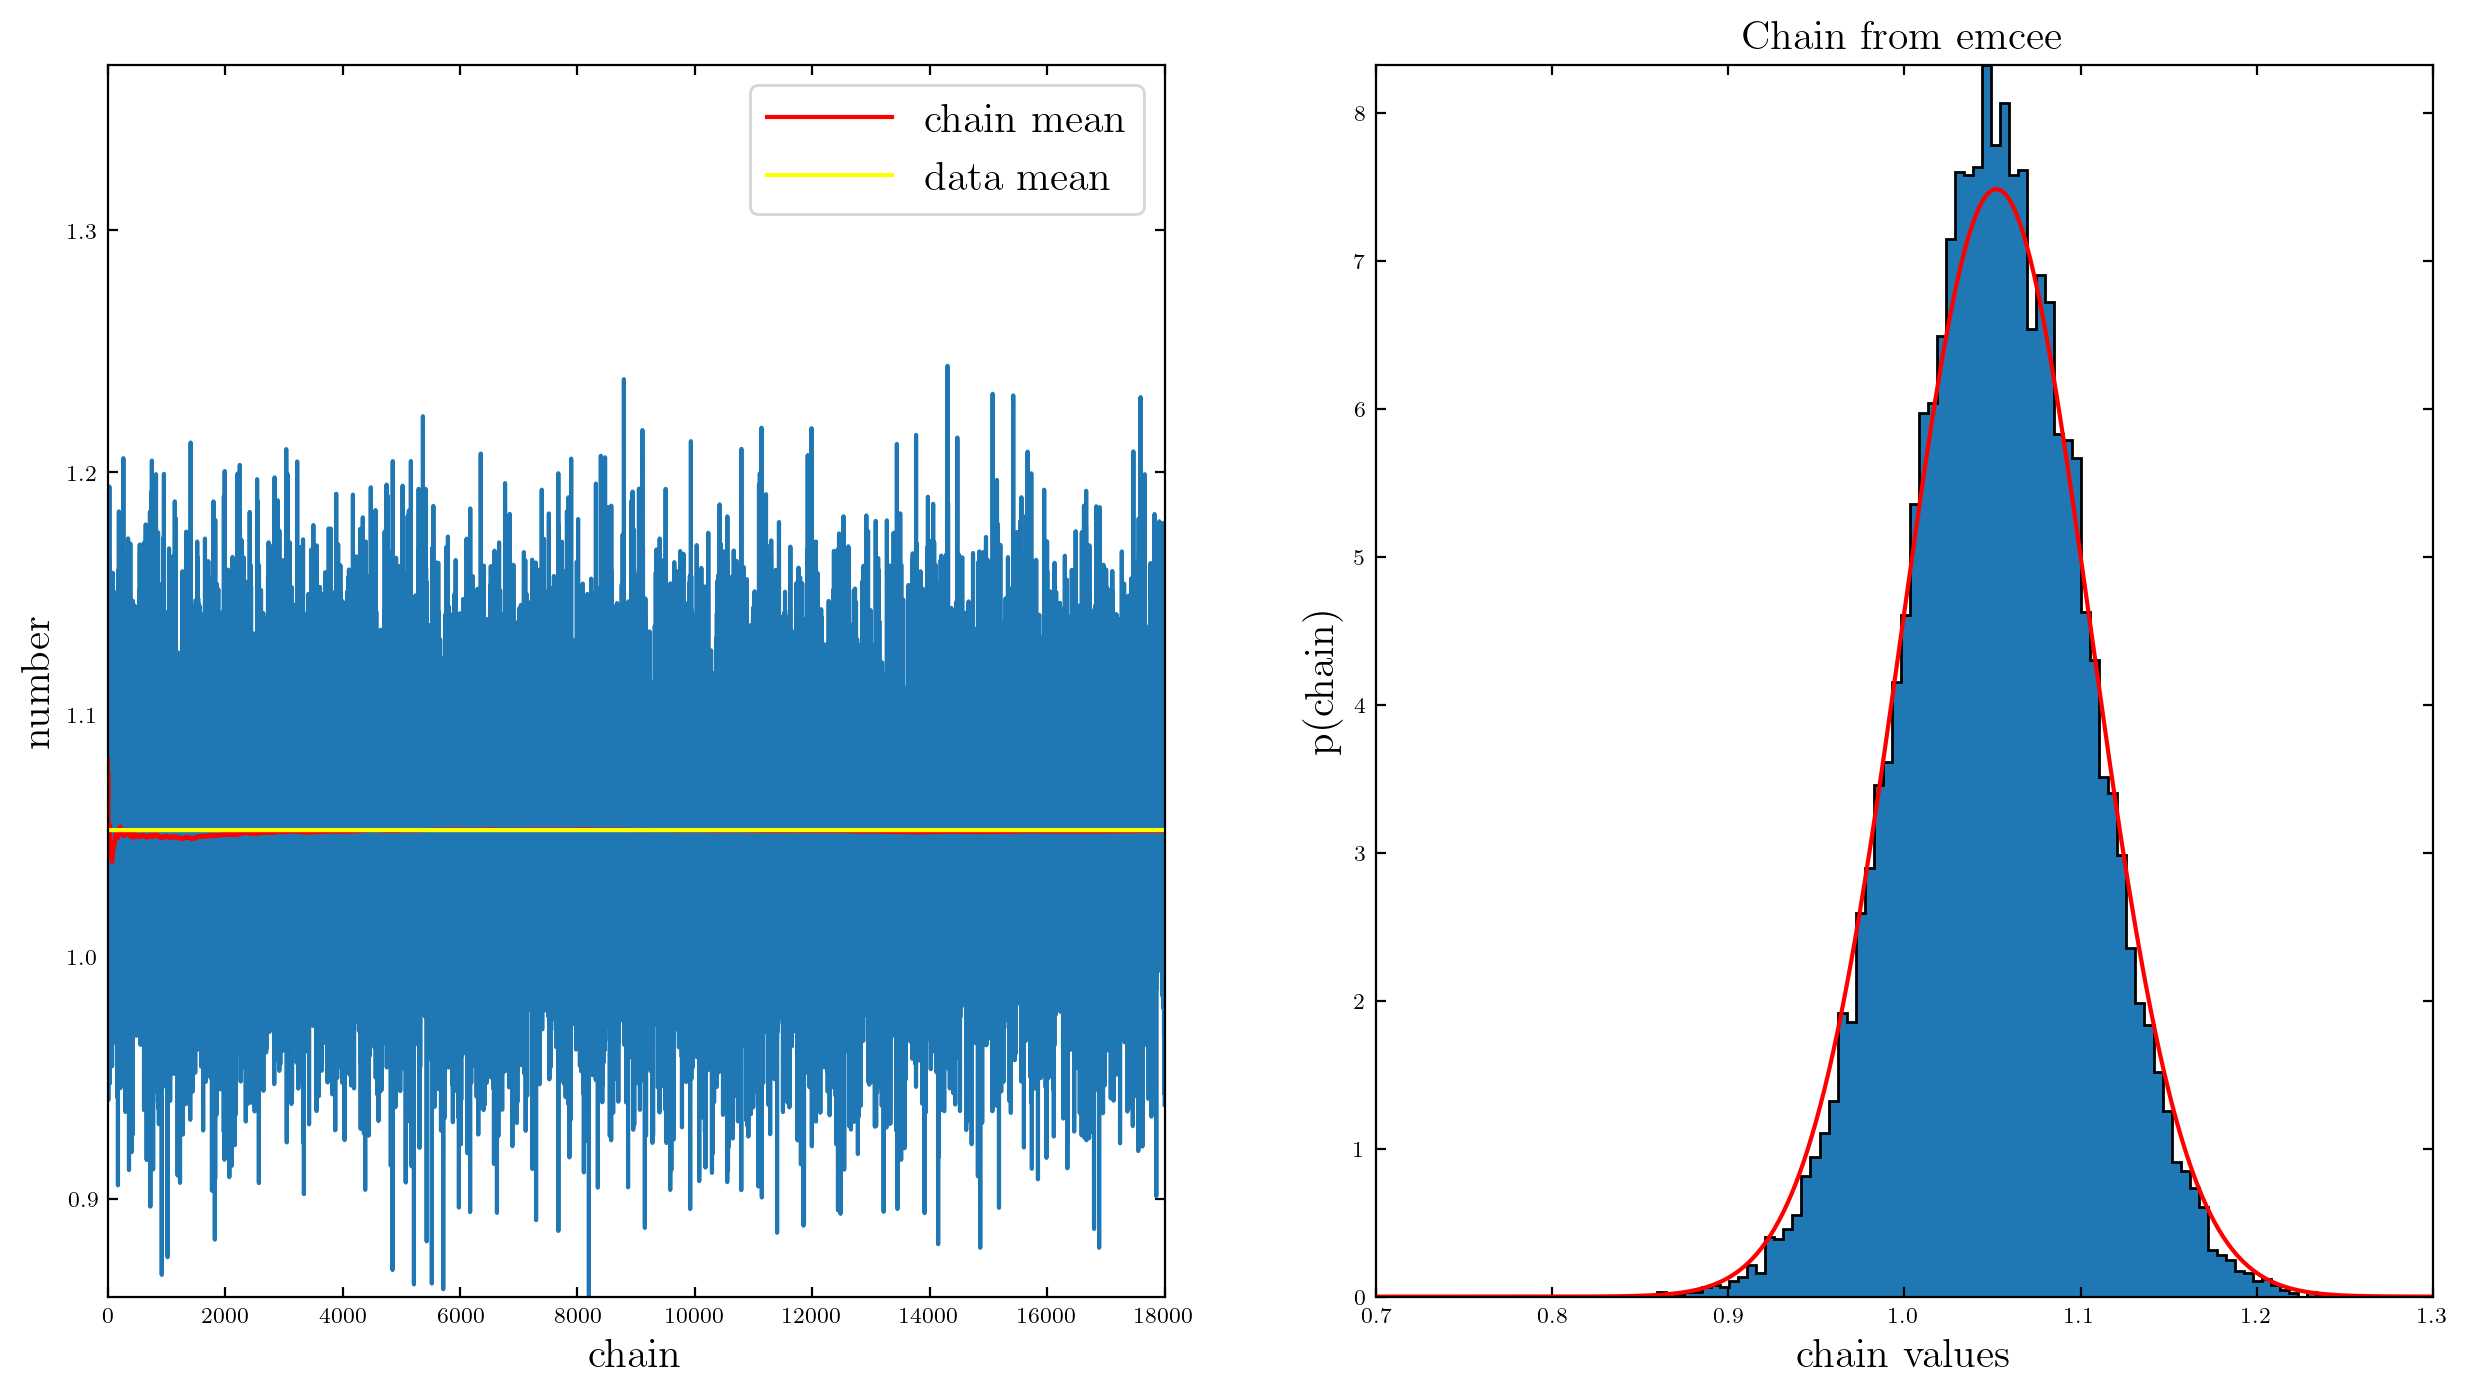

In [21]:
# Lets plot all of this of course so we can see what is going on

plt.rcParams.update({"font.size":22})
fig = plt.figure(figsize = (15,8))

chainE = emcee_trace # loads flattened chain values for parameter E
M = np.size(chainE) # Calculates total number of steps stored in the trace array

ax1 = fig.add_subplot(121) # creates the left subplot, 1 row, 2 columns, position 1
xgrid = np.linspace(0, M, M)
ax1.plot(xgrid, chainE)
ax1.axis([0, M, np.min(chainE), 1.1*np.max(chainE)]) # sets the axis boundaries, from 0 to M on x-axis and from minimum chain length to 1.1*max
ax1.set_ylabel("number", fontsize =15)
ax1.set_xlabel("chain", fontsize =15)


# plot running means
meanC = [np.mean(chainE[:int(N)]) for N in xgrid] # computes the cumulative running mean of the trace, from step 1 to step N
ax1.plot(xgrid, meanC, c = "red", label = "chain mean")
ax1.plot(xgrid, 0*xgrid + np.mean(data), c = "yellow", label = "data mean")
ax1.legend(fontsize = 15)

ax2 = fig.add_subplot(122)
Nburn = 1000
Nhist, bins, patches = plt.hist(chainE, bins = "auto", histtype = "stepfilled", density = True )

# Plot expectations based on

bandwidth = bins[1] - bins[0] # width of each histogram bin
muCLT = np.mean(data)
sigCLT = np.std(data)/np.sqrt(N)
muGrid = np.linspace(0.7,1.3, 500)
gauss = stats.norm(muCLT, sigCLT).pdf(muGrid)
ax2.plot(muGrid, gauss, c='red') 

ax2.set_ylabel('p(chain)',fontsize=15)
ax2.set_xlabel('chain values',fontsize=15)
#ax2.set_xlim(0.7, 1.3)
#ax2.set_ylim(0, 1.2*np.max(gauss))
ax2.set_title(r'Chain from emcee',fontsize=15)



### Now what if we wish to use PyMC?

We use pyMC here to get a 2D posterior pdf for location and scale parameters using a smaple drawn from a Cauchy distribution

In [23]:
from scipy.stats import cauchy
import pymc as pm

if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

def cauchy_logL(xi, sigma, mu):
    """Equation 5.74: cauchy likelihood"""
    xi = np.asarray(xi)
    n = xi.size
    shape = np.broadcast(sigma, mu).shape

    xi = xi.reshape(xi.shape + tuple([1 for s in shape]))

    return ((n - 1) * np.log(sigma)
            - np.sum(np.log(sigma ** 2 + (xi - mu) ** 2), 0))

np.random.seed(44)
mu0 = 0
gamma0 = 1
xi = cauchy(mu0, gamma0).rvs(10)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Now set up the model for PyMC

In [24]:
with pm.Model():
    mu = pm.Uniform("mu", -5,5)
    log_gamma = pm.Uniform("log_gamma", -10,10)

    # read this as x is distributed as a Cauchy variable
    x = pm.Cauchy("x", mu, np.exp(log_gamma), observed = xi)

    trace = pm.sample(draws = 12000, tune = 1000, cores = 1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu, log_gamma]


Output()

Sampling 2 chains for 1_000 tune and 12_000 draw iterations (2_000 + 24_000 draws total) took 80 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [ ]:
mu = np.array(trace['posterior']['mu']).flatten()
loggamma = np.array(trace['posterior']['log_gamma']).flatten()


# compute histogram of results to plot below
L_MCMC, mu_bins, gamma_bins = np.histogram2d(        mu,np.exp(loggamma),       bins= (np.linspace(-5, 5, 41),        np.linspace(0, 5, 41)))
L_MCMC[L_MCMC == 0] = 1E-16  # prevents zero-division errors

# ----------------------------------------------------------------------
# Compute likelihood analytically for comparison
mu = np.linspace(-5, 5, 70)
gamma = np.linspace(0.1, 5, 70)
logL = cauchy_logL(xi, gamma[:, np.newaxis], mu)
logL -= logL.max()

p_mu = np.exp(logL).sum(0)
p_mu /= p_mu.sum() * (mu[1] - mu[0])

p_gamma = np.exp(logL).sum(1)
p_gamma /= p_gamma.sum() * (gamma[1] - gamma[0])

hist_mu, bins_mu = np.histogram(mu, bins=mu_bins, density=True)
hist_gamma, bins_gamma = np.histogram(np.exp(loggamma), bins=gamma_bins, density=True)

Now lets actually plot it:

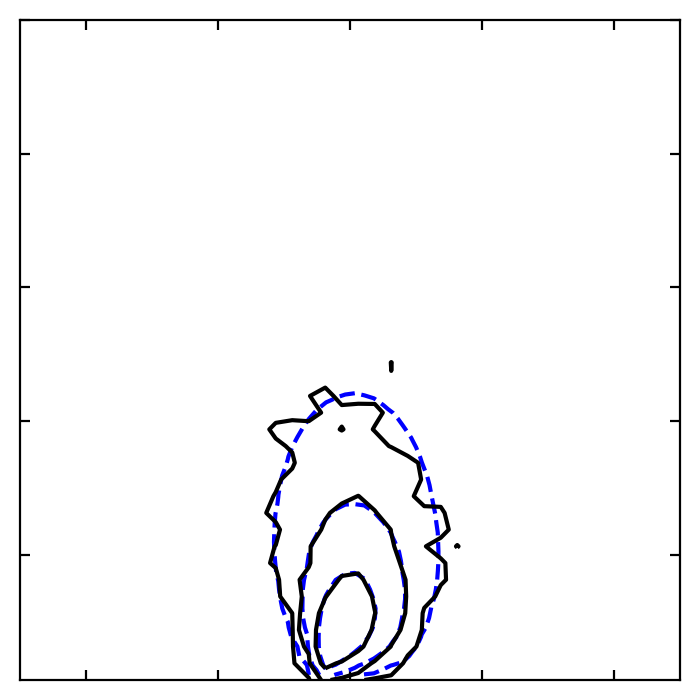

In [27]:
# plot all the results
fig = plt.figure(figsize=(6, 6))

# first axis: likelihood contours
ax1 = fig.add_axes((0.4, 0.4, 0.55, 0.55))
ax1.xaxis.set_major_formatter(plt.NullFormatter())
ax1.yaxis.set_major_formatter(plt.NullFormatter())

ax1.contour(mu, gamma, convert_to_stdev(logL),
            levels=(0.683, 0.955, 0.997),
            colors='b', linestyles='dashed')

ax1.contour(0.5 * (mu_bins[:-1] + mu_bins[1:]),
            0.5 * (gamma_bins[:-1] + gamma_bins[1:]),
            convert_to_stdev(np.log(L_MCMC.T)),
            levels=(0.683, 0.955, 0.997),
            colors='k');

### Gibbs Sampling

This is an MCMC algorithm which completely eliminates rejection and so has an 100% acceptance rate. It breaks down the parameter space into a 1D conditional probability distributions that are sampled while all other parameters stay fixed to their current values.

After sampling for a sufficiently large amount of Gibbs steps, the principle of MCMC guarantee that this process of sequential conditional probability drawing will converge to the joint posterior distribution of the overall model parameter space.

##### So what actually happens?
1. Initialise the sampler at some random point in parameter space
2. Fix all parameters except the first one. Draw a random value from the conditional probability distribution of this first parameter given the fixed values of all other parameters
3. Fix all parameters except the second one. Draw a random value like before, given the fixed values of other parameters, and the updated value of the first parameter
4. Continue for all other parameters
5. Repeat for many Gibbs steps

#### Why do this?

- By drawing from posterior conditionals, the autocorrelation length can be very small with a small amount of burn in.
- It is also fast as we are not rejecting any points

#### Why should we not do this?

- We need to know the form of the conditional probability distributions for each parameter and how to draw samples from it
- This is quite tricky, so we use conjugate priors

Let's analyse a homoscedastic Gaussian dataset but do MCMC sampling and then see how Gibbs sampling works.

In [34]:
# # We know that the general pattern follows:

# def log_likelihood(theta):
#     ...

# def log_prior(theta):
#     ...

# def log_posterior(theta):
#     lp = log_prior(theta)

#     if not np.isfinite(lp):
#         return -np.inf

#     return log_likelihood(theta) + lp

# sampler = emcee.EnsembleSampler(
#     nwalkers,
#     ndim,
#     log_posterior
# )


# sampler.run_mcmc(starting_positions, nsteps)

In [28]:
# Execute this cell
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

from scipy import integrate
from scipy.stats import norm
from astroML.plotting import hist
from astroML.plotting.mcmc import convert_to_stdev
from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=True)
from astroML.plotting.mcmc import convert_to_stdev
import warnings; warnings.simplefilter('ignore')
import corner
import emcee
import time


np.random.seed(21)
Ndata = 200
mu = 1.0
sigma = 1.0
data = stats.norm(mu, sigma).rvs(Ndata)


In [44]:
def likelihood(x):
    return np.sum(stats.norm(loc=x[0], scale = x[1]).logpdf(data))

def Prior(x):

    prior_mu = stats.uniform.pdf(x[0], loc = 0.5, scale = 1.0) # these are uniform priors where mu and sigma are between 0.5 and 1.5
    prior_sigma = stats.uniform.pdf(x[1], loc = 0.5, scale = 1.0)
    return prior_mu * prior_sigma #assumes independance so can multiply probs together

def logposterior(x):
    lp = np.log(Prior(x))
    if not np.isfinite(lp):
        return -np.inf
    else:
        return likelihood(x) + lp

ndim = 2
nwalkers = 5
nsteps = 10000

np.random.seed(0)
starting_guess = np.array([1,1])+1e-3*np.random.randn(nwalkers,ndim)


In [45]:
# Lets actually get the work going

sampler = emcee.EnsembleSampler(nwalkers, ndim, logposterior)

elapsed=time.time()
sampler.run_mcmc(starting_guess, nsteps)
print(time.time()-elapsed)

21.51584529876709


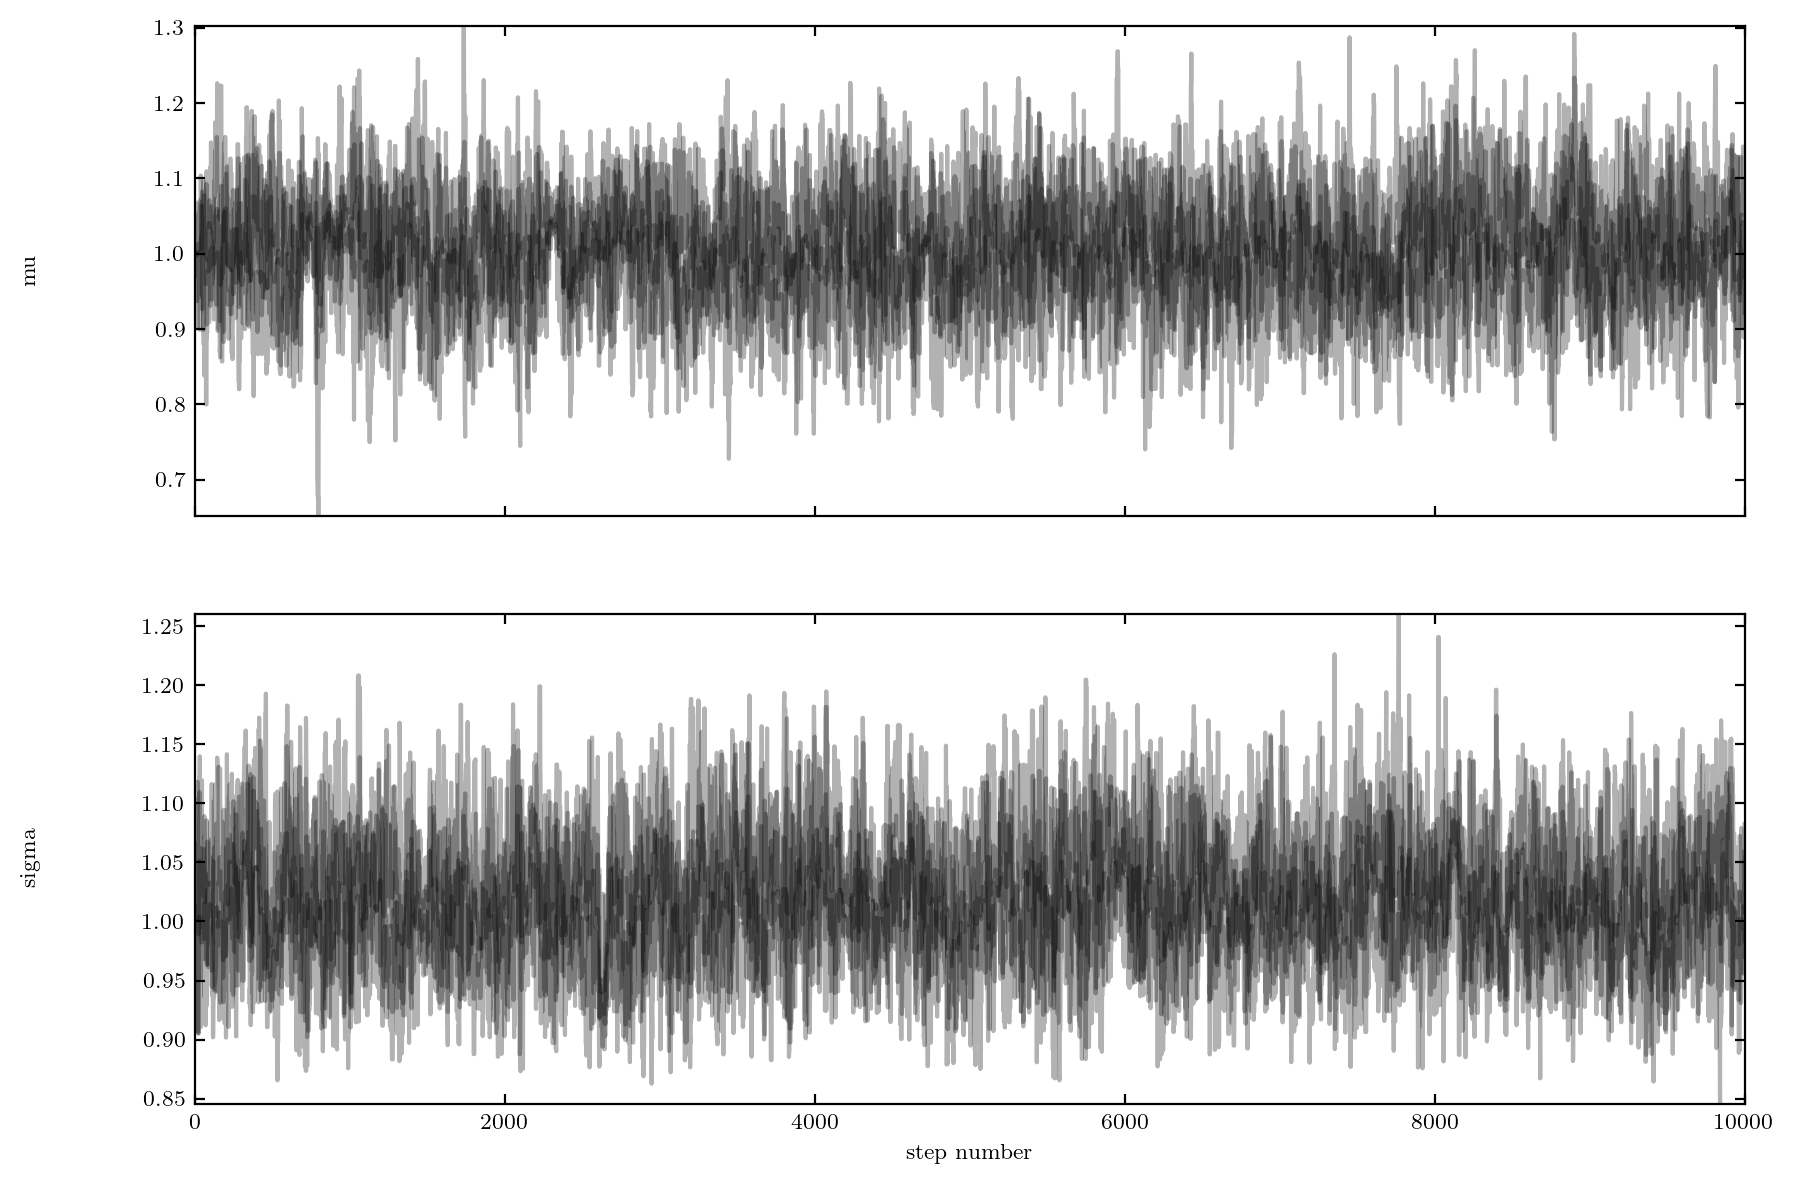

In [46]:
fig, axes = plt.subplots(2, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["mu","sigma"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [47]:
tau = sampler.get_autocorr_time()
print(tau)

[39.51854014 40.57226508]


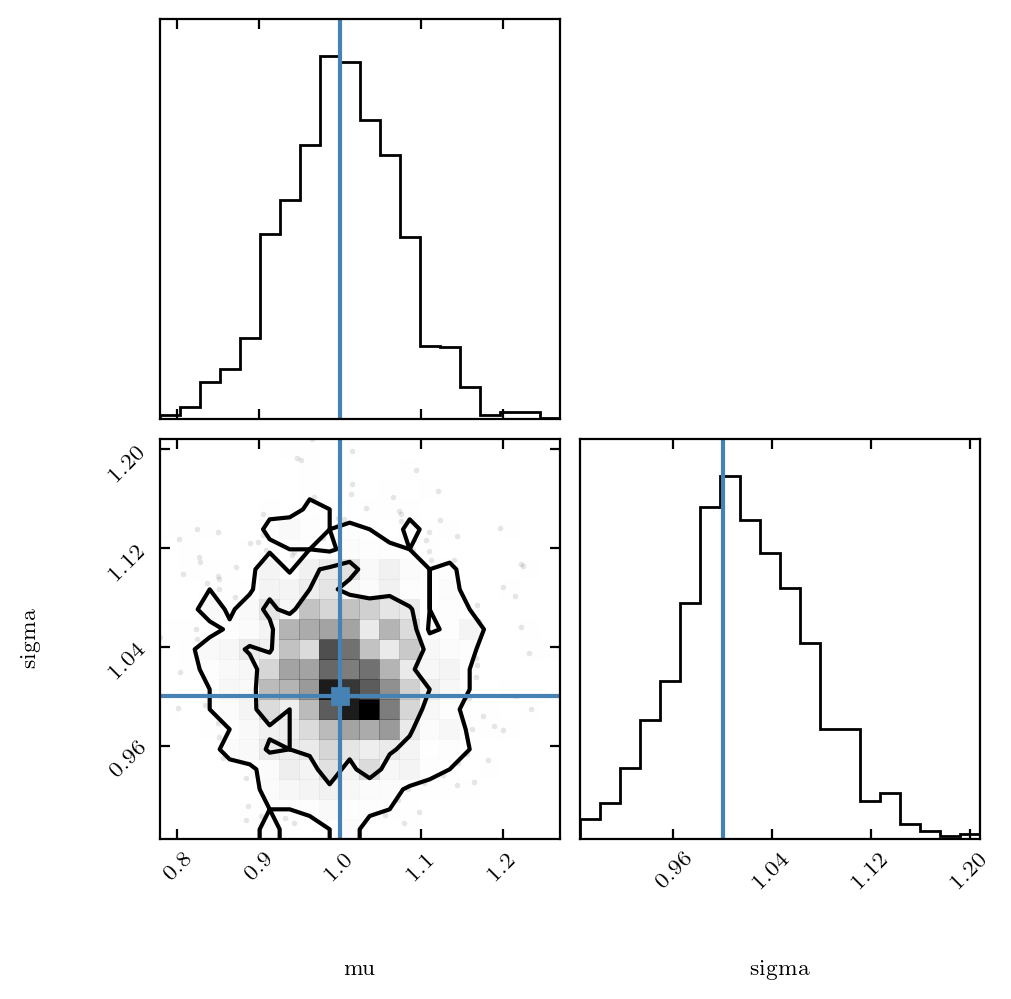

In [48]:
flat_samples = sampler.get_chain(discard=100, thin=30, flat=True)
fig = corner.corner(flat_samples, labels=labels, levels=[0.68,0.95],truths=[1,1]);

My computer is relatively good so this did not take nearly as long as for Gerosa, but I am sure that Gibbs approach will still be quicker. For the purposes of this I shall increase the steps.

It took me around 22s approximately

For Gibbs Approach, we need conjugate priors for the mean and variance of a gaussian likelihood.

These are gaussian for the mean and inverse gamma for the variance. This can be seen when we look at the likelihood of sigma and multiply all $n$ observations together to get a form that looks like an inverse gamma distribution

So,

$$p(\mu) = \mathcal{N}(\mu_0,\sigma_0) = \frac{1}{\sqrt{2\pi\sigma_0^2}}\exp\left(\frac{-\mu^2}{2\sigma_0^2} \right)$$

Where $\alpha, \beta$ are the location and scale parameters of the Gaussian prior on $\mu$ and:

$$p(\sigma^2) = \mathrm{IG}(\alpha,\beta) = \frac{\beta^\alpha}{\Gamma(\alpha)} (1/\sigma^2)^{\alpha+1}\exp(-\beta/\sigma^2)$$

where $\alpha, \beta$ are parameters defining the shape of the inverse gamma prior on $\sigma^2$

So lets get into it!

In [49]:
# conditional of \mu
def p_mu_given_sigma2(sigma2, x, mu0, sigma0):
    sigma_star2 = 1.0 / ( (1.0 / sigma0**2.) + (x.shape[0] / sigma2) )
    mu_star = sigma_star2 * ((mu0/sigma0**2.) + (np.sum(x)/sigma2))
    return np.random.normal(loc=mu_star, scale=np.sqrt(sigma_star2))

# conditional of \sigma^2
def p_sigma2_given_mu(mu, x, alpha, beta):
    alpha_star = alpha + x.shape[0]/2.
    beta_star = beta + np.sum((x-mu)**2.)/2.
    return stats.invgamma.rvs(a=alpha_star, scale=beta_star)


def gibbs_sampling(data, mu_initial, sigma2_initial,
                   mu0, sigma0, alpha, beta, iter=2000):
    samples = np.zeros((iter, 2))
    samples[0,:] = [mu_initial, sigma2_initial]

    for ii in range(1,iter):
        # sequential sampling of posterior conditionals
        ### mu first
        mu_new = p_mu_given_sigma2(samples[ii-1,1], data, mu0, sigma0)
        samples[ii,0] = mu_new
        ### then sigma2
        sigma2_new = p_sigma2_given_mu(samples[ii,0], data, alpha, beta)
        samples[ii,1] = sigma2_new

    return samples

In [50]:
# starting point
mu_initial = 0.2
sigma2_initial = 0.6

# priors
mu0 = 1.0
sigma0 = 0.9
alpha = 1.0
beta = 1.0

## SAMPLE!
def run_gibbs():
    samples = gibbs_sampling(data, mu_initial, sigma2_initial, 
                             mu0, sigma0, alpha, beta)
    return samples

In [51]:
samples = run_gibbs()

Taking every n = 2 samples based on ac length.
Burning first n = 500 samples.


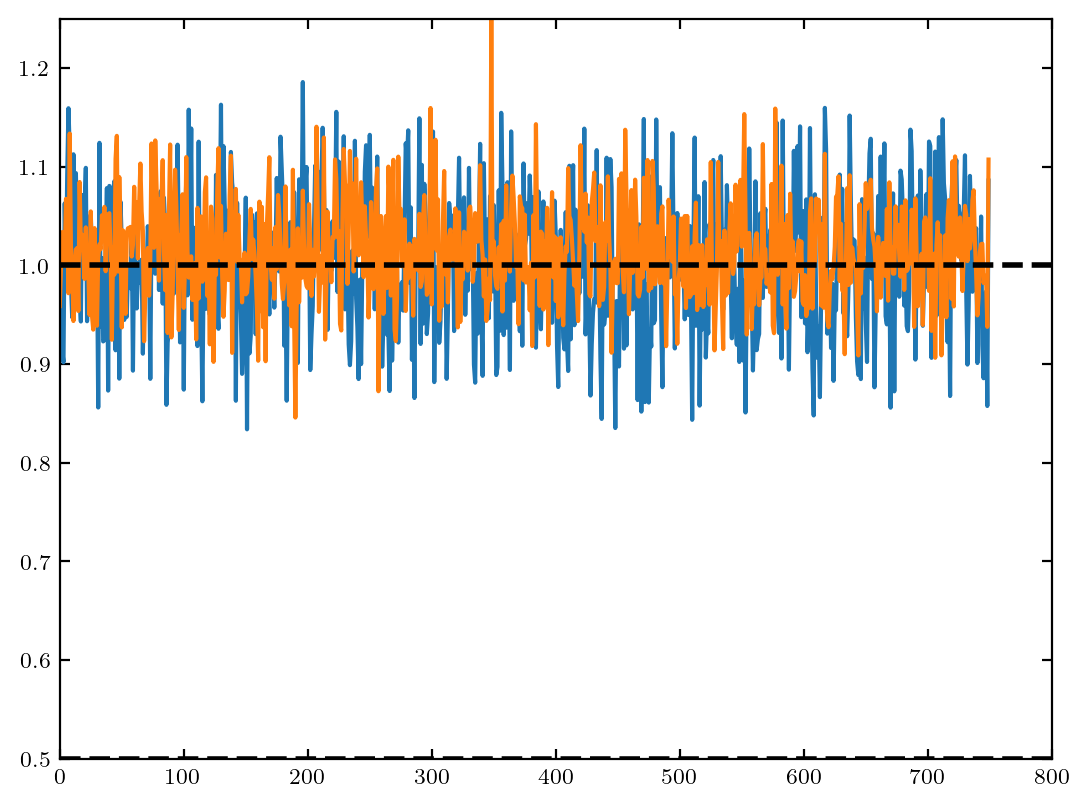

In [52]:
thin = int(emcee.autocorr.integrated_time(samples))+1
print('Taking every n = ' + str(thin) + ' samples based on ac length.')
print('Burning first n = ' + str(500) + ' samples.')

plt.plot(samples[500::thin,0]); # burned and thinned mean
plt.plot(samples[500::thin,1]**0.5); # burned and thinned sigma

# injected values
plt.hlines(1.0, 0.0, 800, color='k', lw=2, ls='dashed');
plt.hlines(0.5, 0.0, 800, color='k', lw=2, ls='dashed');

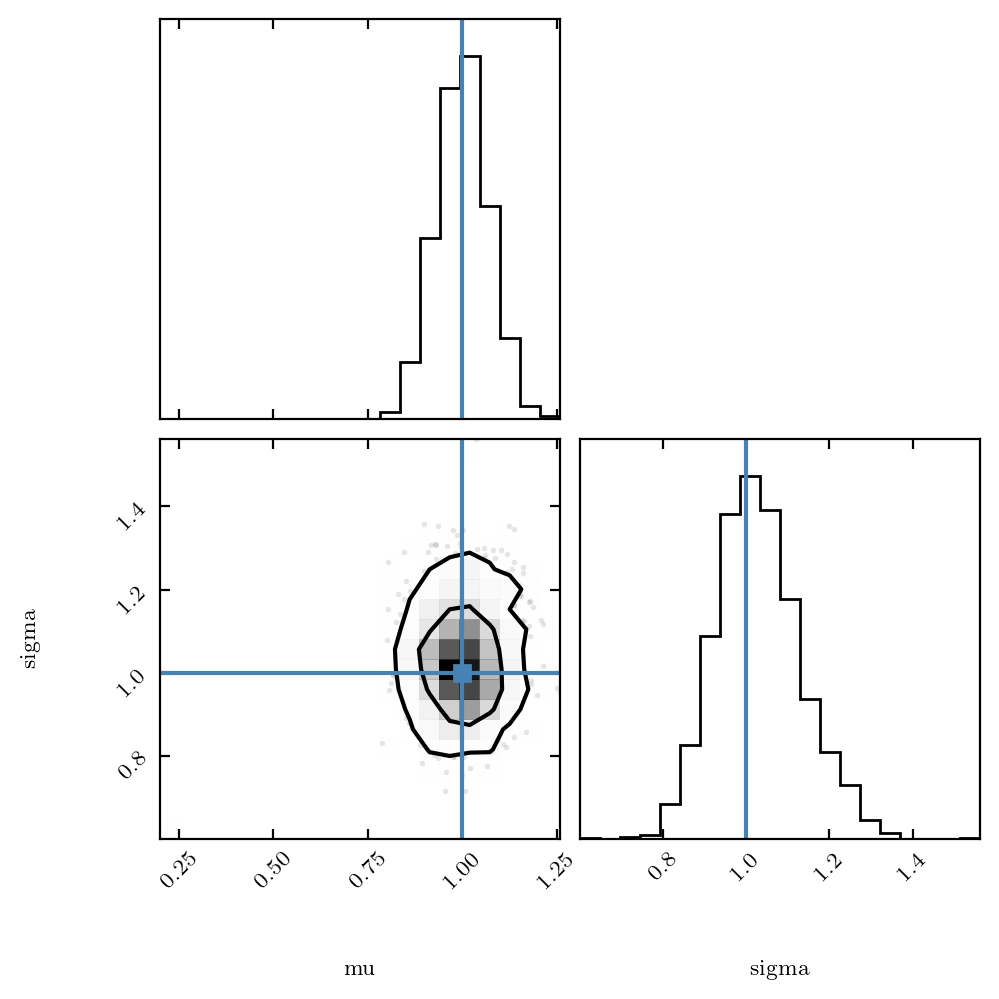

In [53]:
fig = corner.corner(
    samples, labels=labels, levels=[0.68,0.95],truths=[1,1]
);

We can mix and match our stepping algorithms if needed, for example if there are parameters for which we can't directly draw from the conditional posterior, then the Gibbs step for that parameter could be a short Metropolis Hastings MCMC run. 

You can do this with all kinds.

Here, I will use [This MCMC tutorial and recreate it myself (hopefully)](https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial.html). 

Running burn-in...
Running production...


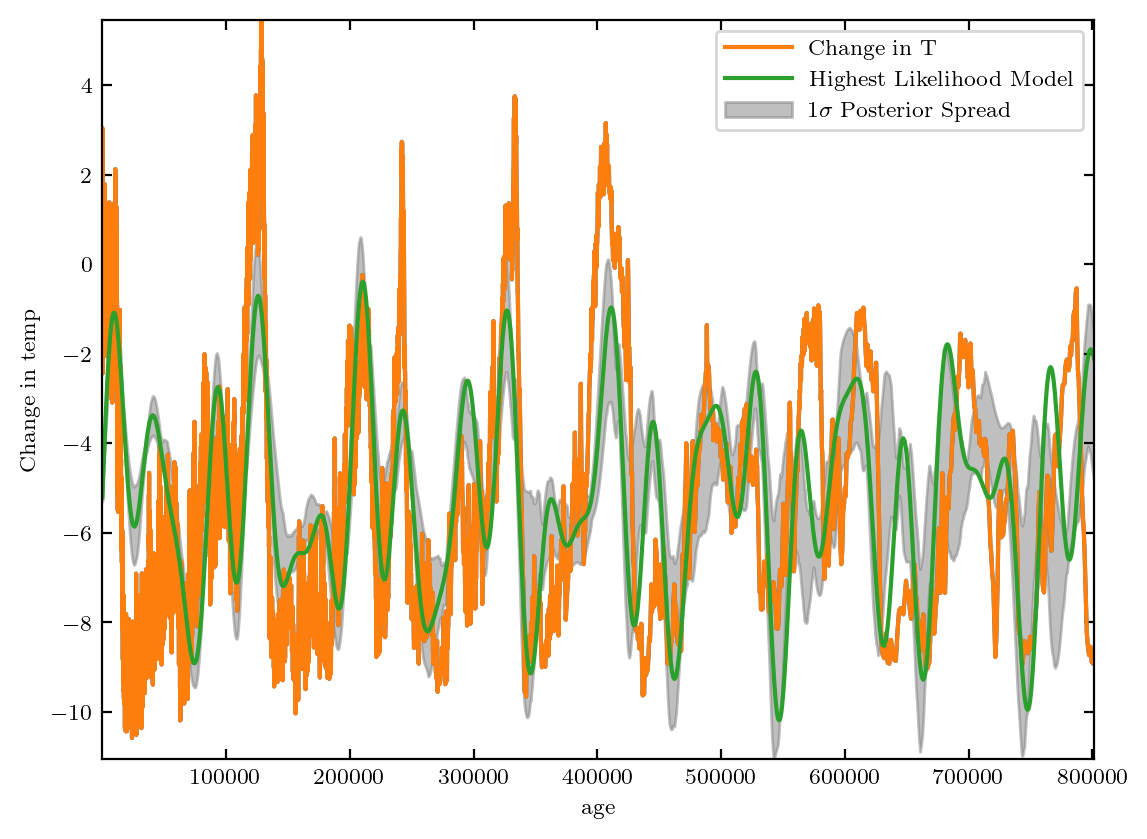

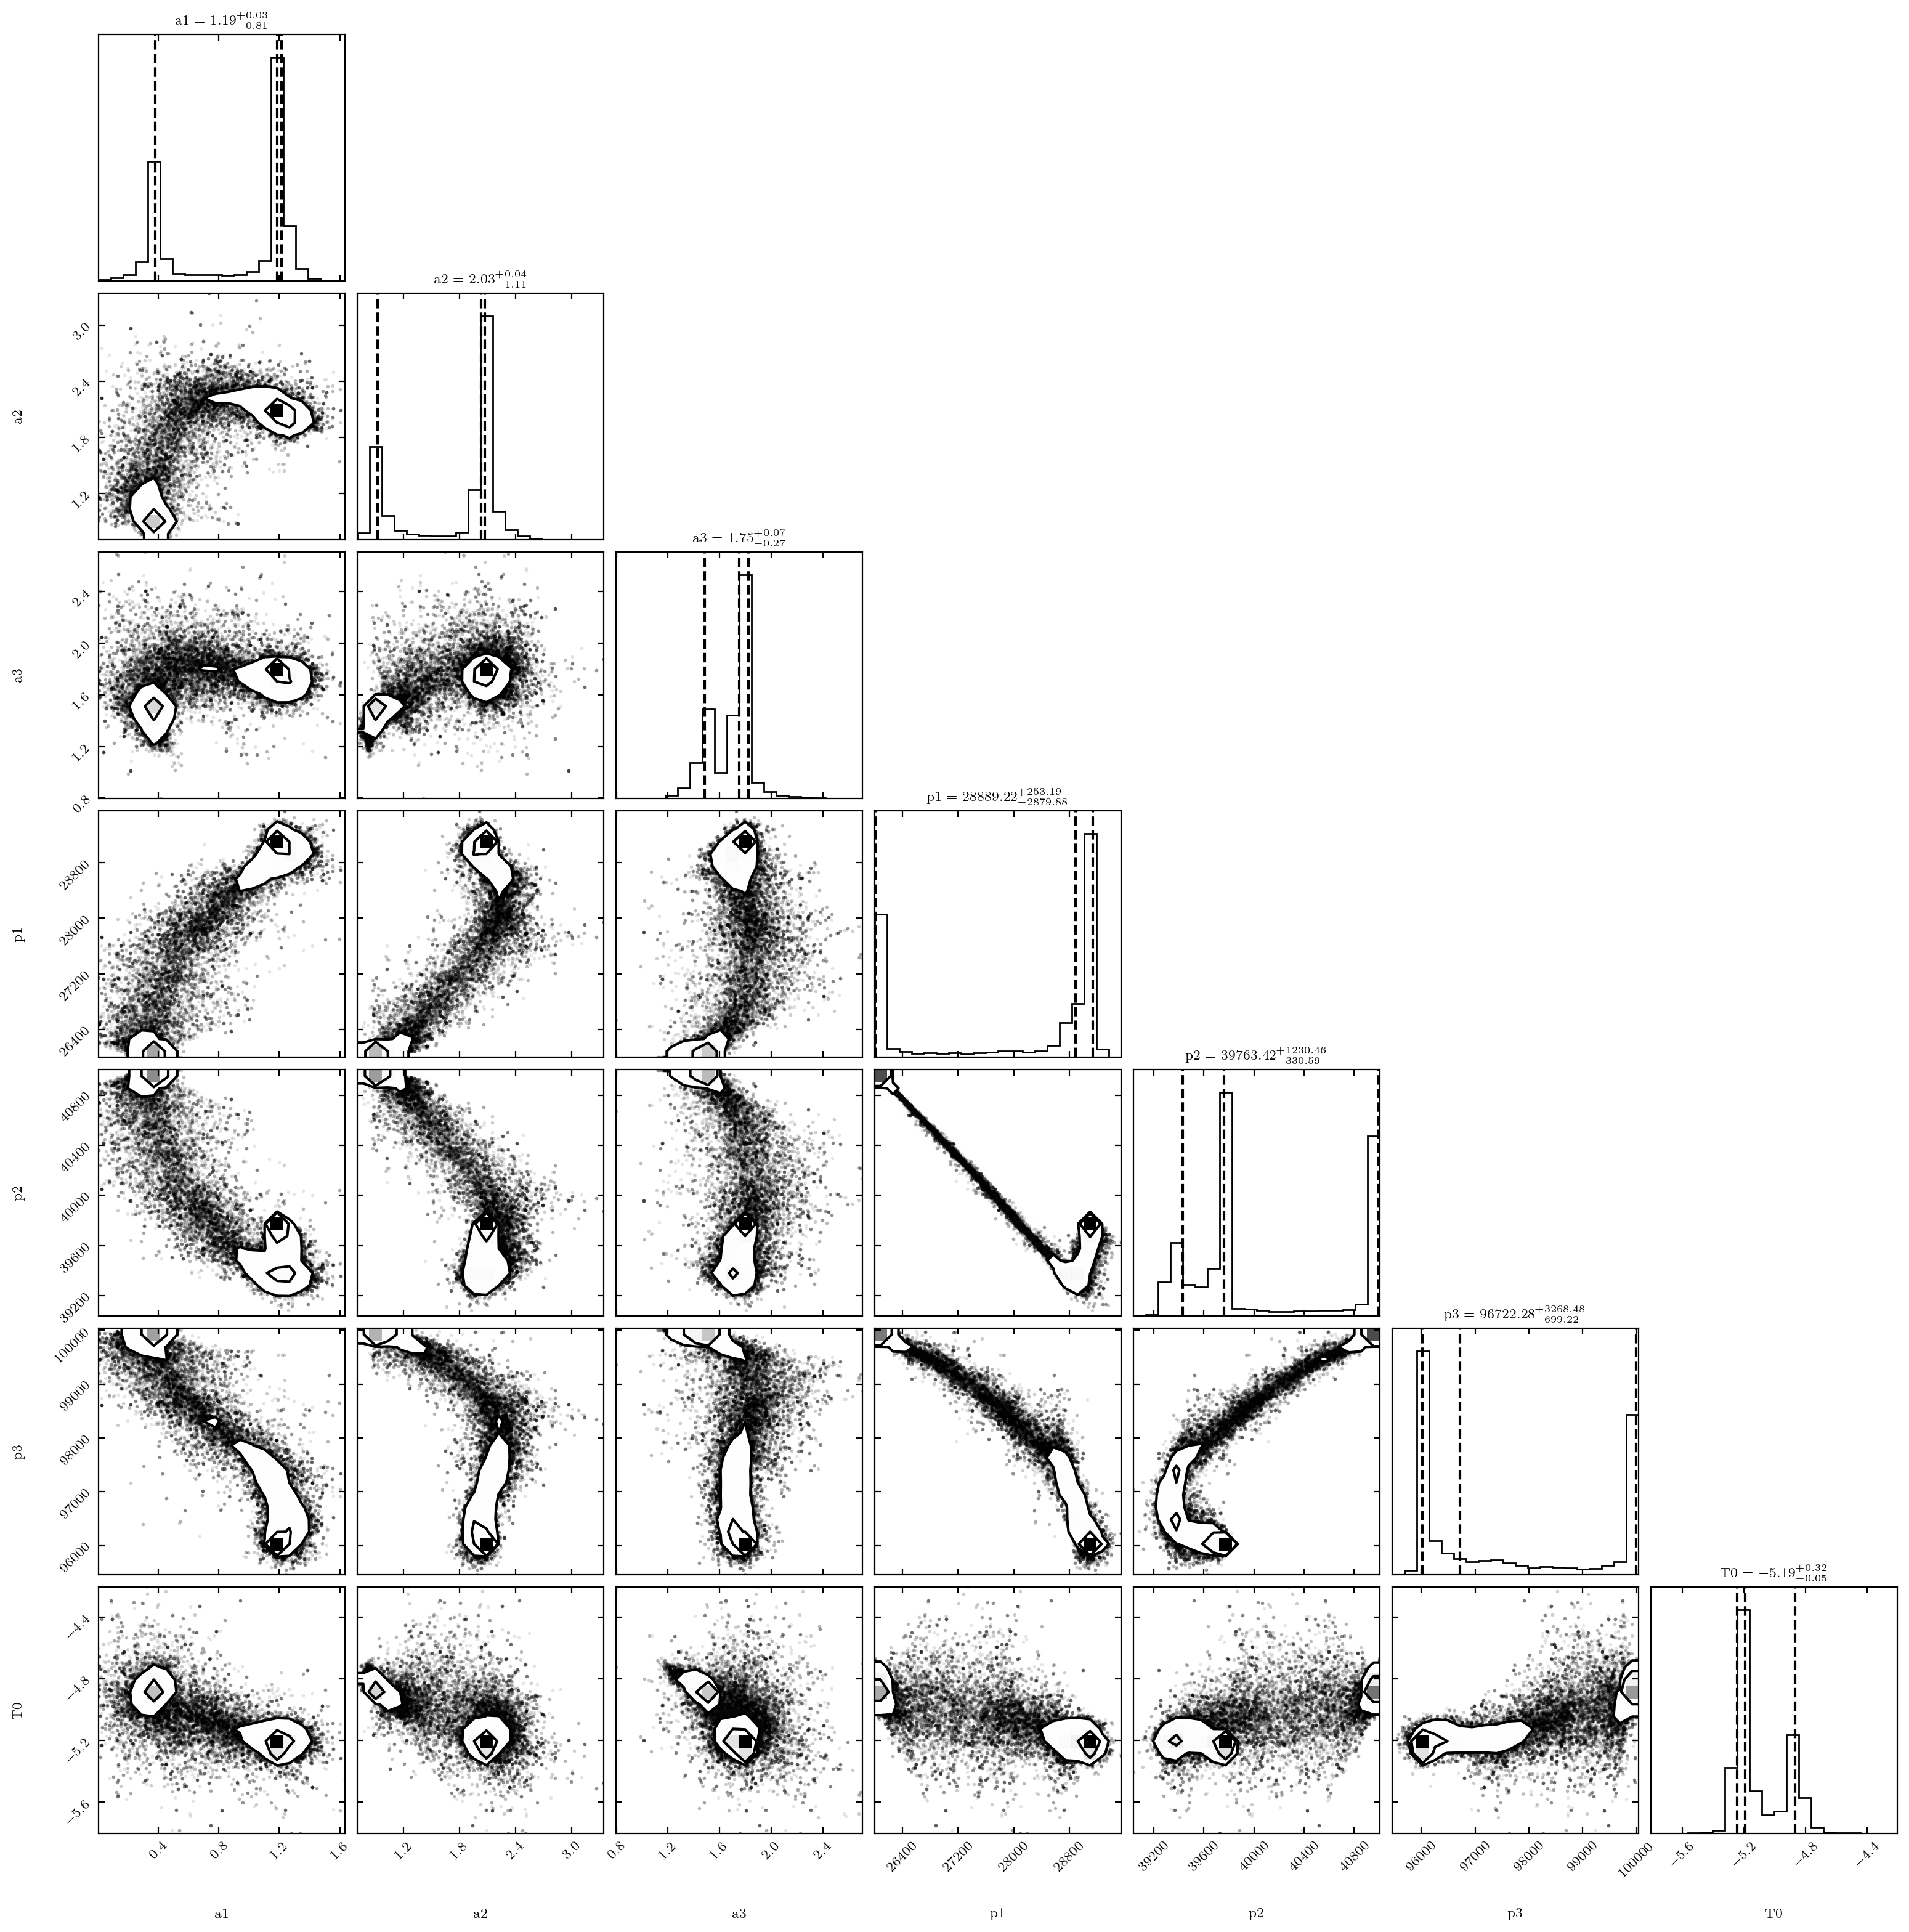

New theta max: [ 1.20398772e+00  2.03192517e+00  1.82324270e+00  2.91392665e+04
  3.97653629e+04  9.60198816e+04 -5.24205169e+00]


In [56]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner



ice_data = np.loadtxt('ice_core_data.txt') 
ice_data = np.transpose(ice_data)
age = ice_data[2]
temps = ice_data[4]

plt.plot(age,temps)

plt.xlabel('age')
plt.ylabel('Change in temp')



def model(theta, age=age):
    a1,a2,a3,p1,p2,p3,T0 = theta
    model = a1*np.sin((2*np.pi *age)/p1) + a2*np.sin((2*np.pi *age)/p2) + a3*np.sin((2*np.pi *age)/p3) + T0 
    return model


def lnlike(theta, x, y, yerr):
    LnLike = -0.5*np.sum(((y-model(theta, x))/yerr)**2)
    return LnLike

def lnprior(theta):
    a1,a2,a3,p1,p2,p3,T0 = theta
    if (0<a1<5 and 0<a2<5 and 0<a3<5 and 10000<p1<200000 and 10000<p2<200000 and 10000<p3<200000 and -10<T0<0 ):
        return 0.0
    else:
        return -np.inf

def lnprob(theta, x, y, yerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta,x , y, yerr)

Terr = 0.05*np.mean(temps)
data = (age, temps,Terr)
nwalkers = 240
niter = 500
initial = np.array([1.0, 1.0, 1.0, 26000., 41000.,100000.,-4.5])
ndim = len(initial)
p0 = [np.array(initial) + 1e-7 * np.random.randn(ndim) for i in range(nwalkers)]

def main(p0,nwalkers,niter,ndim,lnprob,data):
    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=data)

    print("Running burn-in...")
    p0, _, _ = sampler.run_mcmc(p0, 100)
    sampler.reset()

    print("Running production...")
    pos, prob, state = sampler.run_mcmc(p0, niter)

    return sampler, pos, prob, state


new_sampler, newpos, newprob, newstate = main(p0,nwalkers,niter,ndim,lnprob,data)

new_samples =  new_sampler.flatchain

def sample_walkers(nsamples,flattened_chain):
    models = []
    draw = np.floor(np.random.uniform(0,len(flattened_chain),size=nsamples)).astype(int)
    thetas = flattened_chain[draw]
    for i in thetas:
        mod = model(i)
        models.append(mod)
    spread = np.std(models,axis=0)
    med_model = np.median(models,axis=0)
    return med_model,spread
med_model, spread = sample_walkers(100,new_samples)

new_theta_max  = new_samples[np.argmax(new_sampler.flatlnprobability)]
new_best_fit_model = model(new_theta_max)
plt.plot(age,temps,label='Change in T')
plt.plot(age,new_best_fit_model,label='Highest Likelihood Model')
plt.fill_between(age,med_model-spread,med_model+spread,color='grey',alpha=0.5,label=r'$1\sigma$ Posterior Spread')
plt.legend()
labels = ['a1','a2','a3','p1','p2','p3','T0']
fig = corner.corner(new_samples,show_titles=True,labels=labels,plot_datapoints=True,quantiles=[0.16, 0.5, 0.84])
plt.show()
print(f'New theta max: {new_theta_max}')

Okay, I'll be honest I had a few peaks at the code for this, but I did a majority of it myself so thats good, I feel ready to attempt the final problem in lecture 11!

### RESOURCES

[Autocorrelation analysis and convergence](https://emcee.readthedocs.io/en/stable/tutorials/autocorr/)